# DO Masked Card Classifier Test Notebook

Run scene segmentation, detect card crops, classify each crop with a mask-conditioned classifier, and group predictions with fixed UNO geometry (`p1` bottom, `p2` right, `p3` top, `p4` left, center in the middle).

## Inference conventions

- This notebook is inference/evaluation only.
- It loads:
  - `project/models/scene_segmenter_unet_small.pth`
  - `project/models/card_classifier_masked_resnet18_do.pth`
  - `project/models/card_classifier_masked_resnet18_classes_do.npy`
  - `project/models/card_classifier_masked_resnet18_config_do.json`
- It does not use pretrained external weights and keeps the existing competition-compliant geometry mapping.

In [ ]:
from pathlib import Path
import sys

candidate_src_dirs = [
    Path.cwd() / "src",
    Path.cwd().parent.parent / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.is_dir():
        parent = src_dir.parent.resolve()
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate do/src directory for imports.")


from src.test_classifier_CNN import (
    TestPipelineConfig,
    initialize_test_pipeline,
    run_labeled_benchmark,
    run_single_image_diagnostics,
)

# Most-used quick knobs
IMAGE_SOURCE = "augmented_scene"
IMAGE_INDEX = 0
IMAGE_ID = None
SEGMENTATION_THRESHOLD = 0.50
CARD_MASK_THRESHOLD = 0.50
CARD_IMG_SIZE = 160
SEGMENTER_IMG_SIZE = 256
# Manual area filter on connected mask components (in pixels).
SEGMENTER_MIN_COMPONENT_AREA = 6000

EVAL_MAX_IMAGES = None
EVAL_RANDOM_SUBSET = True
EVAL_SEED = 42
WORST_K = 7
TOP_K = 7
INSTANCE_MASK_GROWTH_PX = 10

TEST_CFG = TestPipelineConfig(
    image_source=IMAGE_SOURCE,
    image_index=IMAGE_INDEX,
    image_id=IMAGE_ID,
    card_img_size=CARD_IMG_SIZE,
    segmenter_img_size=SEGMENTER_IMG_SIZE,
    card_mask_threshold=CARD_MASK_THRESHOLD,
    segmenter_min_component_area=SEGMENTER_MIN_COMPONENT_AREA,
    instance_mask_growth_px=INSTANCE_MASK_GROWTH_PX,
    eval_threshold=SEGMENTATION_THRESHOLD,
)

BENCHMARK_CFG = {
    "eval_max_images": EVAL_MAX_IMAGES,
    "eval_random_subset": EVAL_RANDOM_SUBSET,
    "eval_seed": EVAL_SEED,
    "eval_threshold": TEST_CFG.eval_threshold,
    "worst_k": WORST_K,
    "top_k": TOP_K,
}

TEST_CFG

TestPipelineConfig(image_source='augmented_scene', image_index=0, image_id=None, card_img_size=160, segmenter_img_size=256, card_mask_threshold=0.5, segmenter_min_component_area=6000, instance_mask_growth_px=5, eval_threshold=0.5)

## Shared Helpers

In [2]:
test_state = initialize_test_pipeline(TEST_CFG)
{
    "image_id": test_state["image_id"],
    "image_path": str(test_state["image_path"]),
    "image_shape": (test_state["image_w"], test_state["image_h"]),
}

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do
Segmenter:    C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\segmenter\used\scene_segmenter_unet_small.pth
Classifier bundle: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_classifier_cnn\used\latest
Classifier:   C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_classifier_cnn\used\latest\card_classifier.pth
[compliance] SceneUNetSmall (segmenter): 1,928,417 trainable params
[compliance] CardClassifier[resnet18_small]: 9,853,134 trainable params
Loaded masked classifier with 54 classes.
Classifier architecture: resnet18_small (stem_width=60)
Card image size: 160 | mask threshold: 0.5 | segmenter min component area: 6000 | instance mask growth: 5px | input channels: 4
Device: cuda
Image source: augmented_scene
Image id:     aug_scene_00000
Image shape:  1280 x 720
Truth cards:  11, active: p1


{'image_id': 'aug_scene_00000',
 'image_path': 'C:\\Users\\doria\\Documents\\EPFL\\IA\\iapr2026do\\project\\training_data\\training_images\\augmented_scenes\\aug_scene_00000.jpg',
 'image_shape': (1280, 720)}

## Segmenter Helpers

Detected boxes: 10
Foreground pixels: 113133


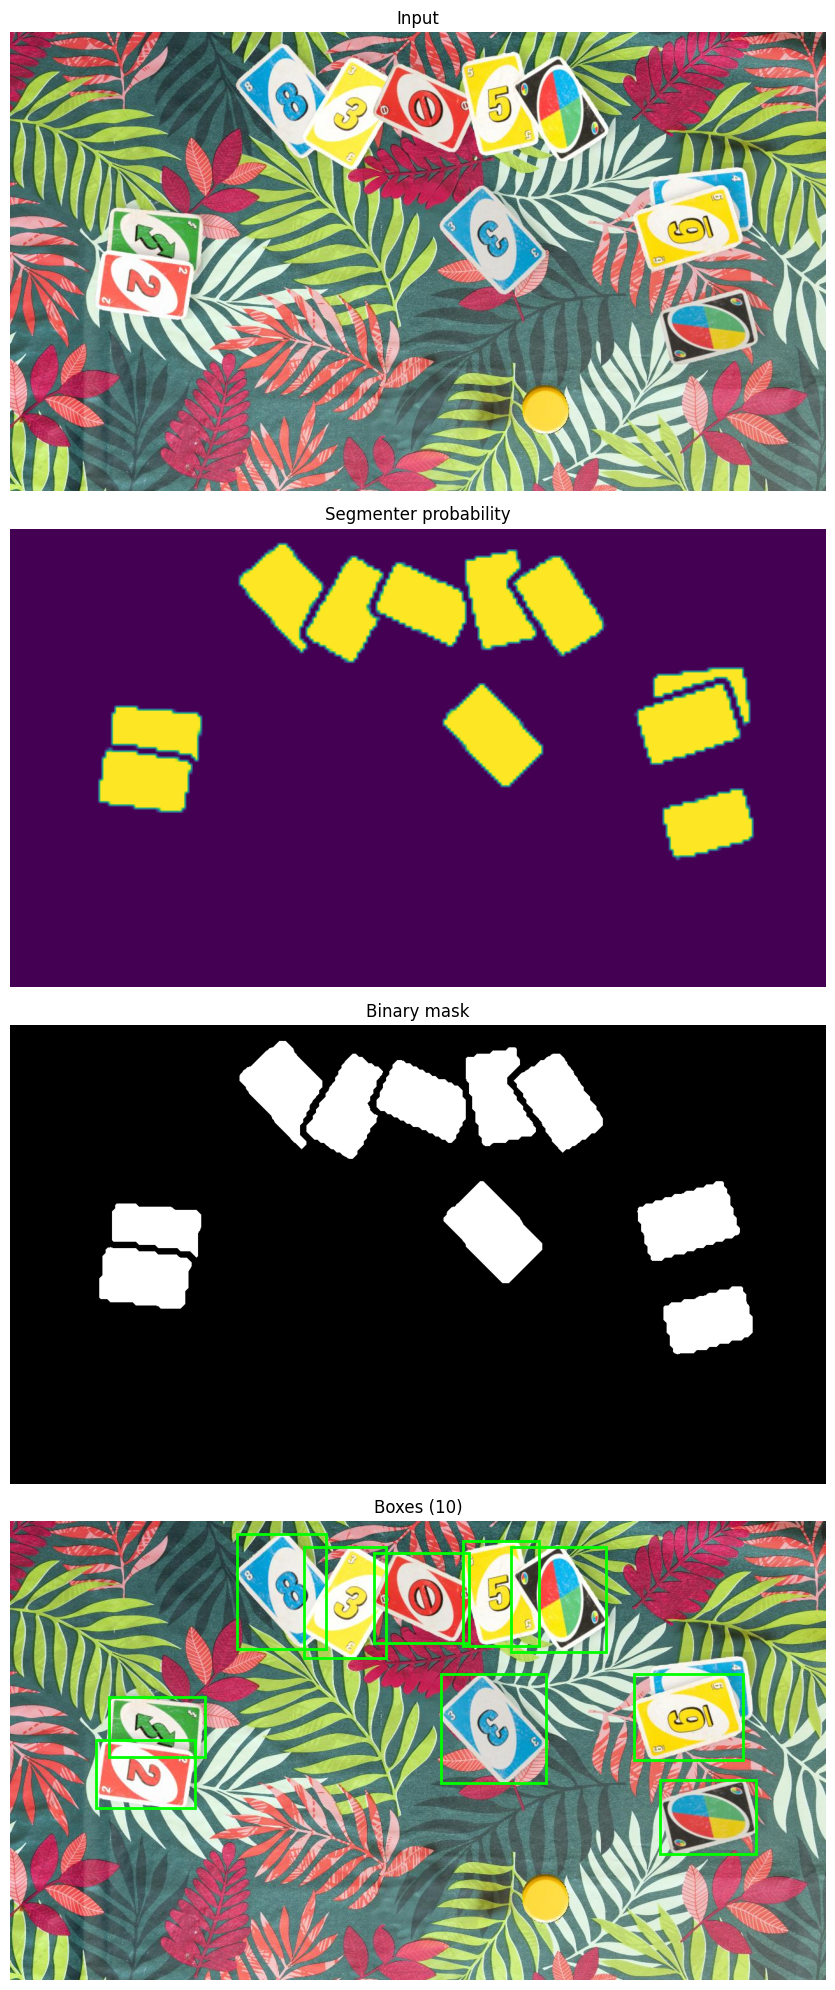

Predictions:
  box 00 (675, 240, 840, 410) -> b_3 [center] conf=0.96 mask_cov=0.37
  box 01 (355, 20, 495, 200) -> b_8 [p3] conf=0.53 mask_cov=0.30
  box 02 (785, 40, 935, 205) -> wild [p3] conf=0.99 mask_cov=0.37
  box 03 (979, 240, 1150, 375) -> y_6 [p2] conf=0.97 mask_cov=0.39
  box 04 (460, 40, 590, 215) -> y_3 [p3] conf=0.25 mask_cov=0.32
  box 05 (570, 50, 720, 190) -> r_skip [p3] conf=0.99 mask_cov=0.43
  box 06 (710, 30, 830, 195) -> y_5 [p3] conf=0.81 mask_cov=0.36
  box 07 (1020, 405, 1170, 522) -> wild [p2] conf=0.99 mask_cov=0.42
  box 08 (135, 343, 290, 450) -> r_2 [p4] conf=0.78 mask_cov=0.42
  box 09 (155, 275, 305, 370) -> g_reverse [p4] conf=0.65 mask_cov=0.35


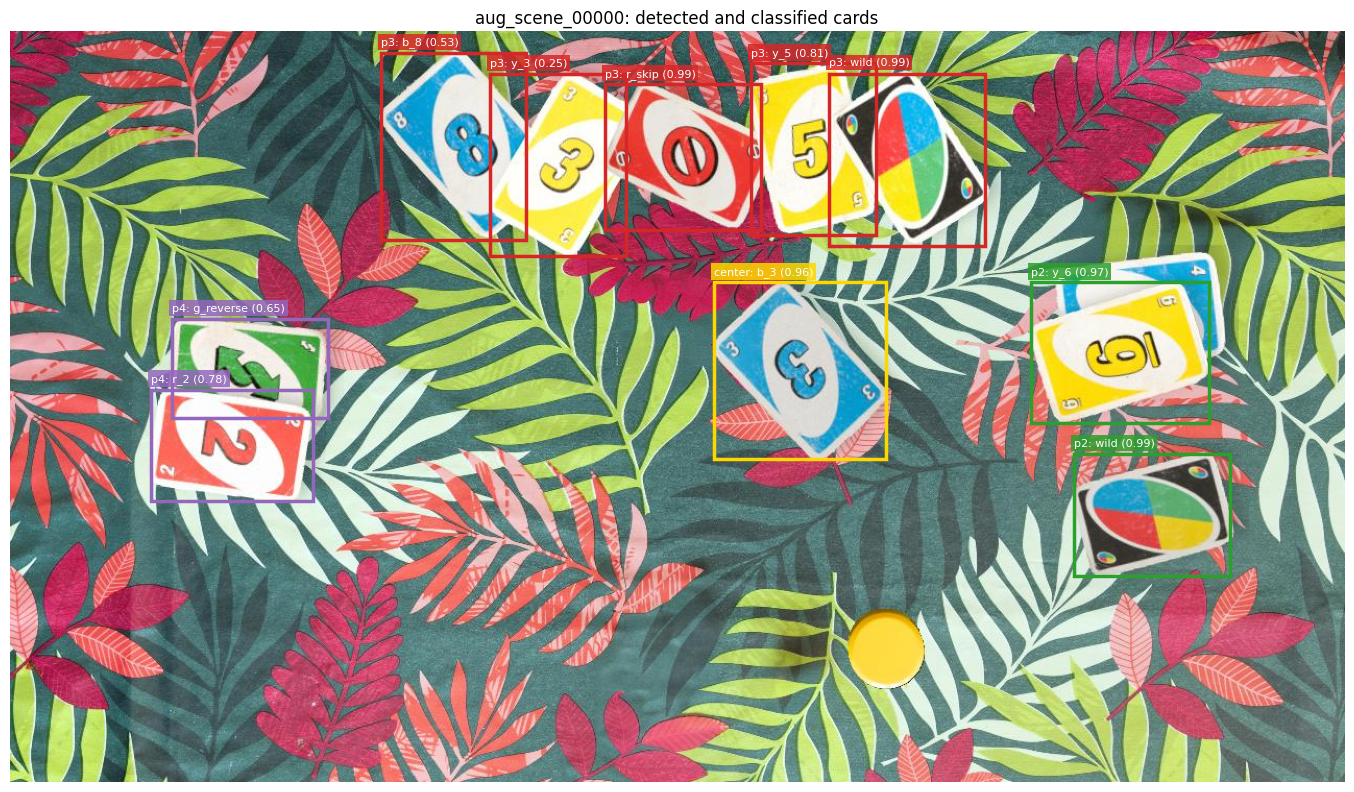


Matched IoU >= 0.30: 10 / 10
Label accuracy on matched boxes:        100.0%
Owner/region accuracy on matched boxes: 100.0%

First matched rows:
  pred=center b_3          | truth=center b_3          | IoU=0.97
  pred=p3     b_8          | truth=p3     b_8          | IoU=0.78
  pred=p3     wild         | truth=p3     wild         | IoU=0.94
  pred=p2     y_6          | truth=p2     y_6          | IoU=0.98
  pred=p3     y_3          | truth=p3     y_3          | IoU=0.86
  pred=p3     r_skip       | truth=p3     r_skip       | IoU=0.90
  pred=p3     y_5          | truth=p3     y_5          | IoU=0.96
  pred=p2     wild         | truth=p2     wild         | IoU=0.95
  pred=p4     r_2          | truth=p4     r_2          | IoU=0.96
  pred=p4     g_reverse    | truth=p4     g_reverse    | IoU=0.87
image_id: aug_scene_00000
center_card: b_3
active_player: p1
player_1_cards: EMPTY
player_2_cards: y_6;wild
player_3_cards: b_8;wild;y_3;r_skip;y_5
player_4_cards: r_2;g_reverse


{'image_id': 'aug_scene_00000',
 'center_card': 'b_3',
 'active_player': 'p1',
 'player_1_cards': 'EMPTY',
 'player_2_cards': 'y_6;wild',
 'player_3_cards': 'b_8;wild;y_3;r_skip;y_5',
 'player_4_cards': 'r_2;g_reverse'}

In [3]:
test_state = run_single_image_diagnostics(test_state, threshold=TEST_CFG.eval_threshold)
test_state.get("summary", {})

## Load Segmenter + Masked Classifier And Pick An Image

In [4]:
test_state.get("pred_rows", [])[:10]

[{'box_index': 0,
  'box': (675, 240, 840, 410),
  'label': 'b_3',
  'confidence': 0.959549605846405,
  'region': 'center',
  'mask_coverage': 0.373828125},
 {'box_index': 1,
  'box': (355, 20, 495, 200),
  'label': 'b_8',
  'confidence': 0.5297302007675171,
  'region': 'p3',
  'mask_coverage': 0.3026171875},
 {'box_index': 2,
  'box': (785, 40, 935, 205),
  'label': 'wild',
  'confidence': 0.9905295968055725,
  'region': 'p3',
  'mask_coverage': 0.374921875},
 {'box_index': 3,
  'box': (979, 240, 1150, 375),
  'label': 'y_6',
  'confidence': 0.9650125503540039,
  'region': 'p2',
  'mask_coverage': 0.3864453125},
 {'box_index': 4,
  'box': (460, 40, 590, 215),
  'label': 'y_3',
  'confidence': 0.24806594848632812,
  'region': 'p3',
  'mask_coverage': 0.32296875},
 {'box_index': 5,
  'box': (570, 50, 720, 190),
  'label': 'r_skip',
  'confidence': 0.9902982115745544,
  'region': 'p3',
  'mask_coverage': 0.4346875},
 {'box_index': 6,
  'box': (710, 30, 830, 195),
  'label': 'y_5',
  'con

In [5]:
test_state.get("summary", {})

{'image_id': 'aug_scene_00000',
 'center_card': 'b_3',
 'active_player': 'p1',
 'player_1_cards': 'EMPTY',
 'player_2_cards': 'y_6;wild',
 'player_3_cards': 'b_8;wild;y_3;r_skip;y_5',
 'player_4_cards': 'r_2;g_reverse'}

## Segment Cards

In [6]:
BENCHMARK_CFG

{'eval_max_images': None,
 'eval_random_subset': True,
 'eval_seed': 42,
 'eval_threshold': 0.5,
 'worst_k': 7,
 'top_k': 7}

## Classify Masked Card Crops And Group By Table Geometry

In [ ]:
benchmark = run_labeled_benchmark(test_state, BENCHMARK_CFG)
{
    key: benchmark[key]
    for key in [
        "center_acc", "p1_f1", "p2_f1", "p3_f1", "p4_f1",
        "macro_f1", "overall", "overall_strict",
        "segmenter_count_quality", "avg_abs_card_count_diff",
        "avg_signed_card_count_diff", "avg_region_abs_card_count_diff",
        "cards_total_true", "cards_total_pred",
    ]
}

Evaluating on 81 labeled original images from C:\Users\doria\Documents\EPFL\IA\iapr2026do\data\iapr-26-uno-vision-challenge\train.csv...
  processed 25/81
  processed 50/81


## Synthetic-Scene Check

In [ ]:
benchmark["worst_results"][:5]

[{'image_id': 'L1000978',
  'image_path': WindowsPath('C:/Users/doria/Documents/EPFL/IA/iapr2026do/data/iapr-26-uno-vision-challenge/train_images/L1000978.jpg'),
  'pred_summary': {'image_id': 'L1000978',
   'center_card': 'y_8',
   'active_player': 'unknown',
   'player_1_cards': 'r_7;b_draw_2;b_2',
   'player_2_cards': 'b_4;g_6',
   'player_3_cards': 'y_4;y_draw_2',
   'player_4_cards': 'r_reverse;r_6'},
  'true_summary': {'image_id': 'L1000978',
   'center_card': 'y_8',
   'active_player': 'p3',
   'player_1_cards': 'r_7;b_0;b_9',
   'player_2_cards': 'g_5;b_4',
   'player_3_cards': 'y_4;y_5',
   'player_4_cards': 'r_reverse;r_9'},
  'pred_rows': [{'box_index': 0,
    'box': (292, 1232, 849, 1696),
    'label': 'r_reverse',
    'confidence': 0.9917041063308716,
    'region': 'p4',
    'mask_coverage': 0.3743359375},
   {'box_index': 1,
    'box': (3261, 1013, 3833, 1461),
    'label': 'b_4',
    'confidence': 0.9588509202003479,
    'region': 'p2',
    'mask_coverage': 0.3761328125}

## Game-State Style Summary

This formats CardUNet predictions into the same game-state style row structure:
one center card and one card list per player (`p1..p4`). Active-player prediction remains handled by the turn/token detector.

In [ ]:
benchmark["top_results"][:5]

[{'image_id': 'L1000770',
  'image_path': WindowsPath('C:/Users/doria/Documents/EPFL/IA/iapr2026do/data/iapr-26-uno-vision-challenge/train_images/L1000770.jpg'),
  'pred_summary': {'image_id': 'L1000770',
   'center_card': 'y_1',
   'active_player': 'unknown',
   'player_1_cards': 'EMPTY',
   'player_2_cards': 'g_2;y_4;r_3',
   'player_3_cards': 'r_skip;y_2;b_5',
   'player_4_cards': 'EMPTY'},
  'true_summary': {'image_id': 'L1000770',
   'center_card': 'y_1',
   'active_player': 'p3',
   'player_1_cards': 'EMPTY',
   'player_2_cards': 'y_4;g_2;r_3',
   'player_3_cards': 'r_skip;y_2;b_5',
   'player_4_cards': 'EMPTY'},
  'pred_rows': [{'box_index': 0,
    'box': (1839, 1247, 2350, 1821),
    'label': 'y_1',
    'confidence': 0.9737173318862915,
    'region': 'center',
    'mask_coverage': 0.3737109375},
   {'box_index': 1,
    'box': (3229, 1028, 3789, 1430),
    'label': 'g_2',
    'confidence': 0.958277702331543,
    'region': 'p2',
    'mask_coverage': 0.4066015625},
   {'box_index'

## Benchmark On Original Labeled Dataset (Masked Classifier)

> The official `test_images` split has no public labels, so true performance cannot be computed there. This section evaluates the full segmentation + masked classification pipeline on labeled images from `train.csv` (optionally on a subset), reports metrics, and visualizes worst/top examples.

In [ ]:
# # Optional quick benchmark rerun on a subset.
# quick_benchmark_cfg = {
#     **BENCHMARK_CFG,
#     "eval_max_images": 100,
# }
# quick_benchmark = run_labeled_benchmark(test_state, quick_benchmark_cfg)
# quick_benchmark["overall"]